# 6 — The protocol that ships, and what it says

Notebooks 04 and 05 are the step this one replaced. They scored one 90/10 split and read a
threshold off it; this reads the protocol `src/attrition_serving/modeling/protocol.py` runs, and
it reads it from the files that protocol wrote.

**Nothing is fitted here.** A run is a few minutes of cross-validation, and a notebook that
retrained would publish numbers nobody could check against `reports/`. Every table below opens a
committed artefact; `scripts/run_evaluation.py` is what produced them, and
`uv run python scripts/smoke.py` replays the whole chain and refuses to finish if anything comes
out different.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from attrition_serving.config import PATHS
from attrition_serving.figure_style import PALETTE, apply_style, reference_line, series_colours

apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 24)

summary = json.loads((PATHS.reports / "evaluation_summary.json").read_text(encoding="utf-8"))
protocol = summary["protocol"]
protocol

{'n_splits': 5,
 'n_repeats': 5,
 'seed': 42,
 'target_recall': 0.8,
 'n_rows': 1470,
 'prevalence': 0.16122448979591836,
 'shipped_arm': 'crossfit',
 'shipped_cost_ratio': 8}

## What one run covers

Five folds, five splitting seeds. Every employee is scored five times by a model that never saw
them in training, which is 7 350 scored rows out of 1 470 employees and 1 185 departures out of
237.

Inside each fold, in order: a quarter of the training part is held out, the model is fitted on
the rest, the recalibration is fitted without the scoring fold, the threshold is read off the
held-out quarter, and only then is the scoring fold touched — once.

In [2]:
folds = pd.read_csv(PATHS.reports / "evaluation_cv.csv")
print(f"{len(folds)} rows: {folds['arm'].nunique()} arms x {folds.groupby('arm').size().max()} folds")
folds.groupby("arm")[["average_precision", "roc_auc", "threshold", "recall", "alert_rate"]].agg(
    ["mean", "std"]
).round(3)

75 rows: 3 arms x 25 folds


average_precision        roc_auc        threshold        recall        alert_rate       
                      mean    std    mean    std      mean    std   mean    std       mean    std
arm                                                                                              
crossfit             0.569  0.058   0.820  0.028     0.107  0.030  0.784  0.095      0.397  0.104
holdout              0.551  0.057   0.817  0.030     0.138  0.051  0.820  0.087      0.449  0.122
none                 0.607  0.058   0.823  0.029     0.411  0.084  0.802  0.086      0.409  0.103

## The three arms, and the trade between them

The service returns a number it calls `proba_depart` and writes it to a database column of the
same name, so it has to be a probability. `class_weight="balanced"` makes the scores rank well
and stops them being one.

Read the two columns together. Recalibration costs average precision and buys a probability
scale: isotonic regression is a step function, it maps distinct scores onto one value, and ties
are what average precision penalises. ROC AUC barely moves, which is how the ordering can be
seen to have survived.

In [3]:
arms = pd.DataFrame(
    {
        arm: {
            "average precision": block["average_precision_mean"],
            "± across folds": block["average_precision_sd"],
            "roc auc": block["roc_auc_mean"],
            "calibration error": block["calibration"]["ece"],
            "mean predicted risk": block["calibration"]["mean_predicted"],
            "recall optimism": block["recall_optimism"],
        }
        for arm, block in summary["arms"].items()
    }
).T.round(4)
arms

,average precision,± across folds,roc auc,calibration error,mean predicted risk,recall optimism
none,0.6074,0.0582,0.8230,0.2141,0.3753,0.0074
holdout,0.5506,0.0572,0.8168,0.0197,0.1635,0.0310
crossfit,0.5687,0.0583,0.8196,0.0147,0.1633,0.0597


## What a returned probability is worth

The published reliability curve, arm by arm, in equal-population bins. The diagonal is what a
calibrated model would trace; the horizontal line is the base rate.

The raw scores sit far below the diagonal over the whole upper range: where the model said 0.57,
the observed departure rate was 0.17. Both isotonic arms sit on it.

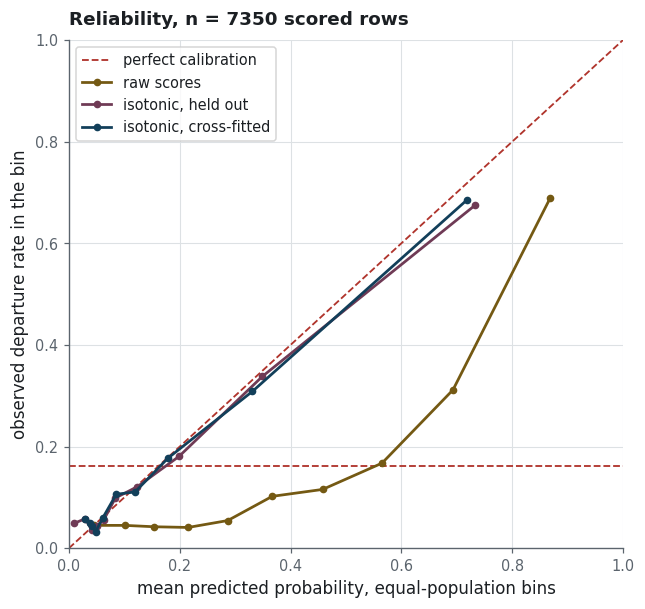

In [4]:
calibration = pd.read_csv(PATHS.reports / "calibration.csv")
labels = {"none": "raw scores", "holdout": "isotonic, held out", "crossfit": "isotonic, cross-fitted"}
colours = series_colours(list(labels.values()))

figure, axis = plt.subplots(figsize=(6.5, 6))
reference_line(axis, diagonal=True, label="perfect calibration")
reference_line(axis, y=protocol["prevalence"])
for arm, label in labels.items():
    block = calibration[calibration["arm"] == arm]
    axis.plot(block["mean_predicted"], block["observed_rate"], marker="o", markersize=4,
              color=colours[label], label=label)
axis.set_xlabel("mean predicted probability, equal-population bins")
axis.set_ylabel("observed departure rate in the bin")
axis.set_title(f"Reliability, n = {summary['arms']['none']['n_rows_scored']} scored rows")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.legend(loc="upper left", frameon=True)
plt.show()

## The threshold is a cost decision

A model ranks. It does not say where a retention conversation starts, and that line depends on
what a departure costs compared with an hour spent on a conversation nobody needed.

The repository ships the ratio of eight and publishes the whole curve, because eight is an
assumption and the one number an employer would replace with their own. Past a ratio of about 13
the list covers half the company and stops being a list.

In [5]:
curve = pd.read_csv(PATHS.reports / "cost_curve.csv")
shipped = protocol["shipped_cost_ratio"]
curve.assign(
    threshold=curve["threshold_mean"].round(3),
    flagged=(curve["alert_rate_mean"] * 100).round(0).astype(int).astype(str) + " %",
    caught=(curve["recall_mean"] * 100).round(0).astype(int).astype(str) + " %",
    precision=curve["precision_mean"].round(2),
    shipped=curve["ratio"].eq(shipped).map({True: "<- shipped", False: ""}),
)[["ratio", "threshold", "flagged", "caught", "precision", "shipped"]]

,ratio,threshold,flagged,caught,precision,shipped
0,1,0.546,8 %,36 %,0.77,
1,2,0.366,13 %,50 %,0.62,
2,3,0.277,18 %,59 %,0.53,
3,5,0.162,26 %,69 %,0.44,
4,8,0.110,37 %,78 %,0.35,<- shipped
5,13,0.065,53 %,87 %,0.27,
6,20,0.052,64 %,91 %,0.24,
7,30,0.021,98 %,100 %,0.16,


## Who the alert list lands on

Alert rate and recall per subgroup, at the shipped threshold. No correction is applied and no
fairness claim is made.

Two readings. Every group is flagged at roughly twice its own departure rate, so none is
over-flagged relative to how often it actually leaves. Recall is less even: 86 % of departures
among single employees, 63 % among married ones — a retention programme built on this list would
systematically miss more people in one group than another.

The smallest group carries 315 scored rows, which is 63 employees scored five times. Its number
rests on about twelve departures, and one employee moves it by eight points.

In [6]:
subgroups = pd.read_csv(PATHS.reports / "subgroups.csv")
subgroups.assign(
    flagged=(subgroups["alert_rate"] * 100).round(0).astype(int).astype(str) + " %",
    caught=(subgroups["recall"] * 100).round(0).astype(int).astype(str) + " %",
    ratio=(subgroups["alert_rate"] / subgroups["base_rate"]).round(1),
)[["attribute", "group", "n", "n_positive", "base_rate", "flagged", "caught", "ratio"]]

,attribute,group,n,n_positive,base_rate,flagged,caught,ratio
0,gender,female,2940,435,0.147959,34 %,77 %,2.3
1,gender,male,4410,750,0.170068,39 %,76 %,2.3
2,marital status,single,2350,600,0.255319,50 %,86 %,2.0
3,marital status,divorced,1635,165,0.100917,26 %,78 %,2.6
4,marital status,married,3365,420,0.124814,32 %,63 %,2.6
5,department,Sales,2230,460,0.206278,45 %,79 %,2.2
6,department,R&D,4805,665,0.138398,32 %,75 %,2.3
7,department,HR,315,60,0.190476,46 %,82 %,2.4


## What the earlier split was worth

The 90/10 split of notebooks 04 and 05, recomputed under this protocol's seed, against the 25
folds that replaced it.

It runs the opposite way from what one would expect: the published split gave an average
precision **below** most of the folds. The repository was under-reporting its own model, and the
correction moved the number up rather than down.

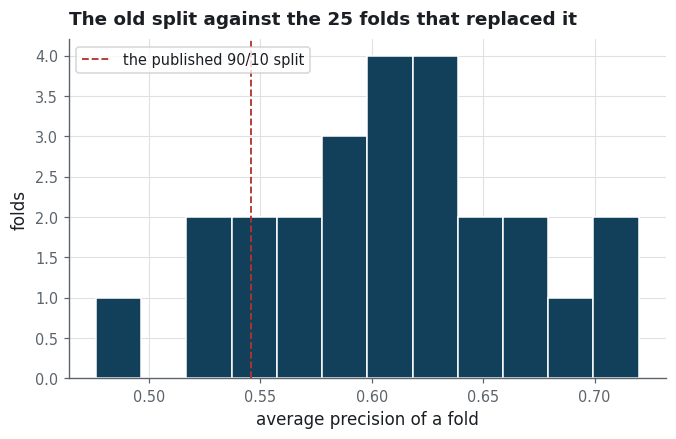

the 90/10 split scored 0.546 on 147 rows (24 departures) — above 16% of the folds


In [7]:
split = summary["single_split"]
percentile = summary["single_split_ap_percentile"]

figure, axis = plt.subplots(figsize=(7, 4))
raw = folds[folds["arm"] == "none"]["average_precision"]
axis.hist(raw, bins=12, color=PALETTE["primary"], edgecolor=PALETTE["paper"])
reference_line(axis, x=split["average_precision"], label="the published 90/10 split")
axis.set_xlabel("average precision of a fold")
axis.set_ylabel("folds")
axis.set_title(f"The old split against the {len(raw)} folds that replaced it")
axis.legend(loc="upper left", frameon=True)
plt.show()

print(
    f"the 90/10 split scored {split['average_precision']:.3f} on {split['n_test']} rows "
    f"({split['n_positive']} departures) — above {percentile:.0%} of the folds"
)

## What this leaves

The shipped operating point, the artefact that carries it, and the two claims the service makes
on every request: the threshold it decided at, and the version of the model that decided.

Everything above is in `docs/protocol.md` in prose, with the six corrections that produced it.
What is not here, and not anywhere: a causal claim. A column that separates leavers from stayers
may be a symptom of the decision to leave, and a cross-section cannot tell the two apart.

In [8]:
card = json.loads((PATHS.models / "model_card.json").read_text(encoding="utf-8"))
{
    "arm": card["calibration"],
    "threshold": card["default_threshold"],
    "cost ratio": card["threshold_cost_ratio"],
    "features consumed": card["expected_n_features_raw"],
    "scikit-learn": card["sklearn_version"],
}

{'arm': 'crossfit',
 'threshold': 0.1105,
 'cost ratio': 8,
 'features consumed': 32,
 'scikit-learn': '1.8.0'}